<a href="https://colab.research.google.com/github/ayoelijah83-droid/SQL/blob/main/Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Read File

In [2]:
df = pd.read_csv("branches.csv", on_bad_lines="skip")


Exploring Data

In [3]:
df.shape
df.dtypes
df.head(15)

,Date,Product,Branch,Unit_Price,Quantity,Cost_per_Unit
0,2025-07-07,A,Central,39.28,5.0,8.90
1,2025-07-03,C,Central,28.37,5.0,20.03
2,2025-07-08,C,West,12.26,8.0,25.81
3,2025-07-06,B,East,34.70,6.0,5.18
4,2025-07-09,A,Central,34.47,3.0,14.56
5,2025-07-04,A,Central,44.40,7.0,9.26
6,2025-07-10,A,West,37.37,7.0,20.25
7,2025-07-08,C,Central,46.37,4.0,9.56
8,2025-07-04,B,West,30.80,4.0,9.62
9,2025-07-02,B,West,25.81,4.0,19.95


Checking for duplicate and deleting duplicate

In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Checking for null values

In [5]:
df.isna().sum()


,0
Date,0
Product,0
Branch,0
Unit_Price,1
Quantity,0
Cost_per_Unit,1


Filling the null values with the mean

In [6]:
df.fillna(df[['Unit_Price', 'Cost_per_Unit']].mean(), inplace=True)

Inconsistent Formatting

In [7]:
df['Product']=df['Product'].str.strip().str.title()
df['Branch']=df['Branch'].str.strip().str.title()

Compute Additional Columns

In [8]:
df['Revenue'] = df['Unit_Price'] * df['Quantity']
df['Cost'] = df['Cost_per_Unit'] * df['Quantity']
df['Profit'] = df['Revenue'] - df['Cost']
df['Margin (%)'] = df['Profit'] / df['Revenue'] * 100

Identifies the branch with the highest total revenue.

In [9]:
df[['Branch', 'Revenue']].query('Revenue == Revenue.max()')

,Branch,Revenue
5,Central,310.8


Which branch sells the most units on average per day?

In [10]:
df.groupby(['Branch', 'Date'])['Quantity'].mean().reset_index().query("Quantity == Quantity.max()")

,Branch,Date,Quantity
5,Central,2025-07-10,9.0
7,East,2025-07-02,9.0


Is there a branch that focuses on specific products more than others?

Product,A,B,C
Branch,,,
Central,52.459016,14.754098,32.786885
East,20.833333,52.083333,27.083333
West,52.941176,23.529412,23.529412


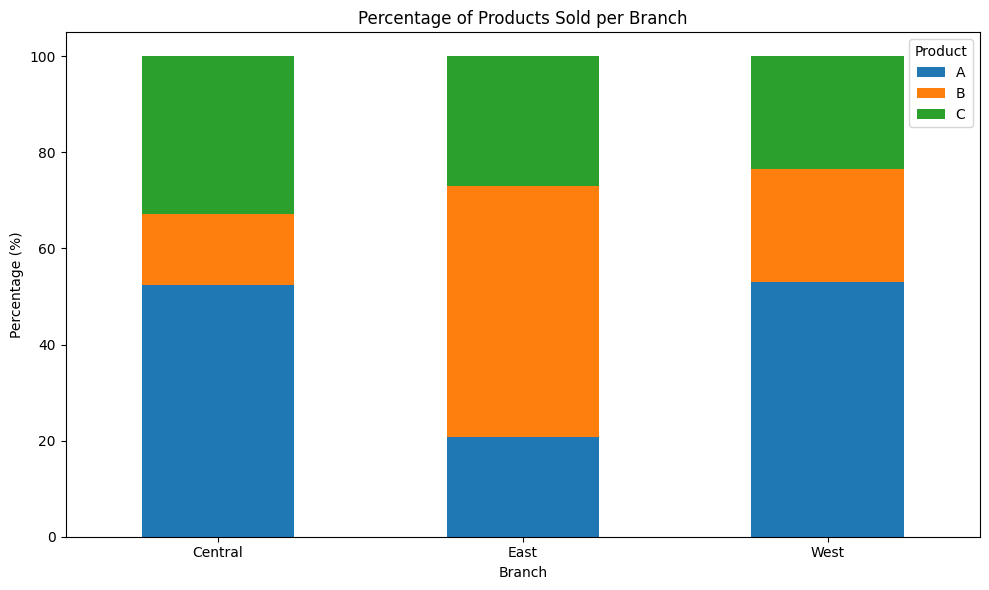

In [11]:
# Calculate the total quantity sold for each product in each branch
product_branch_sales = df.groupby(['Branch', 'Product'])['Quantity'].sum().reset_index()

# Calculate the total quantity sold in each branch
branch_total_sales = df.groupby('Branch')['Quantity'].sum().reset_index()
branch_total_sales.rename(columns={'Quantity': 'Branch_Total_Quantity'}, inplace=True)

# Merge the two dataframes to calculate the percentage
merged_sales = pd.merge(product_branch_sales, branch_total_sales, on='Branch')
merged_sales['Percentage'] = (merged_sales['Quantity'] / merged_sales['Branch_Total_Quantity']) * 100

# Pivot the table for better visualization
pivot_sales = merged_sales.pivot(index='Branch', columns='Product', values='Percentage').fillna(0)

# Display the pivoted table
display(pivot_sales)

# Visualize the distribution of products per branch
pivot_sales.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Percentage of Products Sold per Branch')
plt.xlabel('Branch')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Product')
plt.tight_layout()
plt.show()

Which branch has the highest average unit price?

In [12]:
df.groupby('Branch')['Unit_Price'].mean().reset_index().query('Unit_Price == Unit_Price.max()')

,Branch,Unit_Price
0,Central,29.553333


What is the average cost per unit across branches?

In [13]:
df.groupby('Branch')['Cost_per_Unit'].mean().reset_index()

,Branch,Cost_per_Unit
0,Central,19.406474
1,East,17.331111
2,West,19.285000


Which products have the widest gap between unit price and cost per unit?

In [14]:
# Calculate the difference between unit price and cost per unit for each product
df['Price_Cost_Gap'] = df['Unit_Price'] - df['Cost_per_Unit']

# Group by product and calculate the average gap
average_gap_per_product = df.groupby('Product')['Price_Cost_Gap'].mean().reset_index()

# Sort by the gap in descending order to find the widest gaps
products_widest_gap = average_gap_per_product.sort_values(by='Price_Cost_Gap', ascending=False).max()

print("Products with the widest gap between Unit Price and Cost per Unit (sorted by average gap):")
display(products_widest_gap)

Products with the widest gap between Unit Price and Cost per Unit (sorted by average gap):


,0
Product,C
Price_Cost_Gap,10.132028


Which branch achieves the best cost efficiency (lowest average cost per unit)?

In [15]:
df.groupby('Branch')['Cost_per_Unit'].mean().reset_index().query('Cost_per_Unit == Cost_per_Unit.min()')

,Branch,Cost_per_Unit
1,East,17.331111


Which day of the week has the highest sales?

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day_of_Week'] = df['Date'].dt.day_name()

daily_sales = df.groupby('Day_of_Week')['Revenue'].sum().reset_index()
highest_sales_day = daily_sales.sort_values(by='Revenue', ascending=False).iloc[0]

print("Day of the week with the highest sales:")
display(highest_sales_day)

Day of the week with the highest sales:


,5
Day_of_Week,Wednesday
Revenue,1153.074615


Are sales increasing or decreasing over time (daily/weekly)?

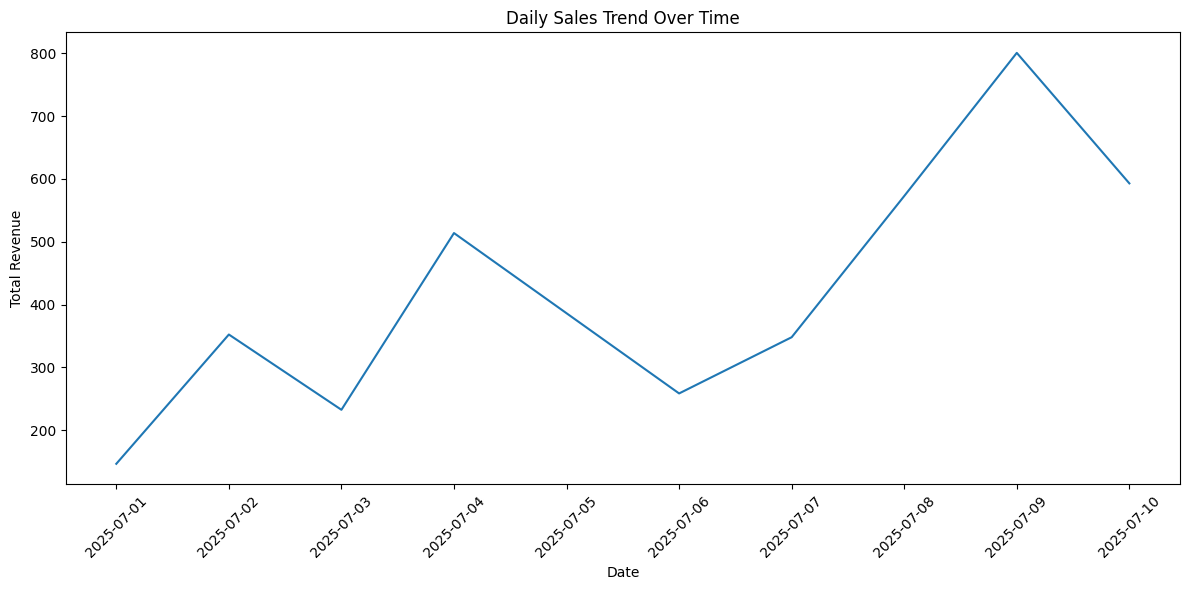

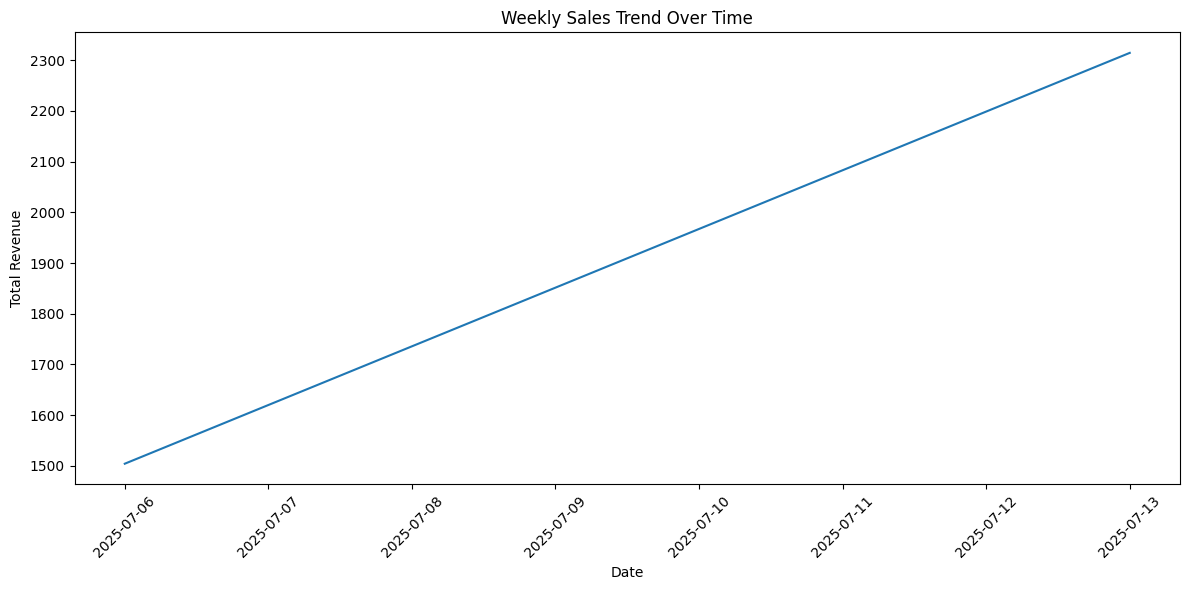

In [18]:
# Group by date and calculate total revenue
daily_sales_trend = df.groupby('Date')['Revenue'].sum().reset_index()

# Resample to weekly frequency and sum the revenue
weekly_sales_trend = daily_sales_trend.resample('W', on='Date')['Revenue'].sum().reset_index()

# Plot daily sales trend
plt.figure(figsize=(12, 6))
plt.plot(daily_sales_trend['Date'], daily_sales_trend['Revenue'])
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot weekly sales trend
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales_trend['Date'], weekly_sales_trend['Revenue'])
plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()